### Ursache-Wirkungs-Prinzip

Das **Ursache-Wirkungs-Prinzip** beschreibt den gerichteten Zusammenhang zwischen Signalen in einem dynamischen System:

* Ursache (Eingang $u(t)$ / Störung $z(t)$): Das Signal oder die Veränderung, die auf das System einwirkt.
* Wirkung (Ausgang $y(t)$): Die zeitlich nachfolgende Reaktion des Systems auf die Ursache.

> Eine Wirkung kann niemals vor ihrer Ursache auftreten.

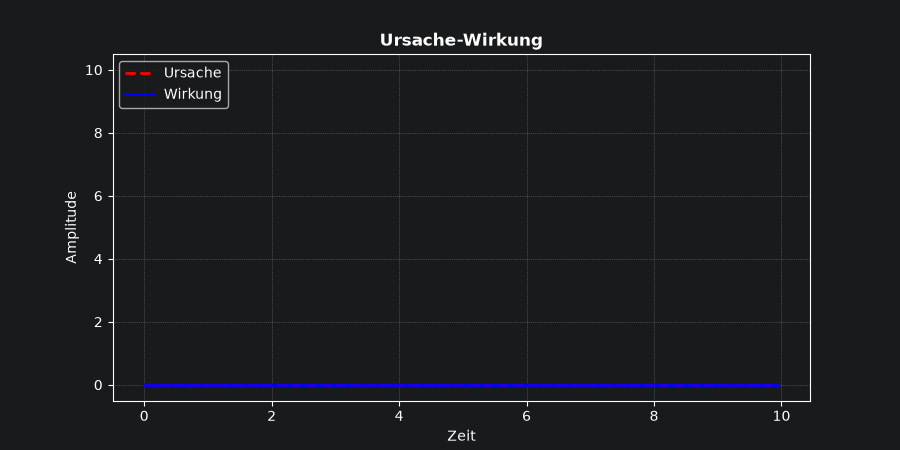

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

# --- 1. Systemparameter & Simulationseinstellungen ---
current_T = 2.0   # Startwert für die Zeitkonstante T (Verzögerung)
K = 1.0           # Verstärkungsfaktor
dt = 0.05         # Zeitschrittweite der Live-Schleife (50ms)
max_points = 200  # Wie viele Datenpunkte gleichzeitig sichtbar sind

# Globale Datenpuffer für den Live-Stream
t_data = np.arange(0, max_points * dt, dt)
u_data = np.zeros(max_points)
y_data = np.zeros(max_points)

# Globale Variable für den aktuellen Zielwert vom Slider
current_target = 0.0

# --- 2. Plot-Setup vorbereiten ---
fig, ax = plt.subplots(figsize=(9, 4.5))
line_u, = ax.plot(t_data, u_data, 'r--', label='Ursache', linewidth=2)
line_y, = ax.plot(t_data, y_data, 'b-', label='Wirkung', linewidth=2)

ax.set_title('Ursache-Wirkung', fontsize=12, fontweight='bold')
ax.set_xlabel('Zeit')
ax.set_ylabel('Amplitude')
ax.set_ylim(-0.5, 10.5)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

# --- 3. Die Update-Funktion für die Animation (Live-Feed) ---
def update(frame):
    global y_data, u_data

    # Letzten Zustand holen
    y_old = y_data[-1]
    u_now = current_target

    # PT1-Differenzengleichung mit der aktuell eingestellten Zeitkonstante
    y_new = y_old + (dt / current_T) * (K * u_now - y_old)

    # Daten-Arrays nach links verschieben (Scroll-Effekt)
    u_data = np.append(u_data[1:], u_now)
    y_data = np.append(y_data[1:], y_new)

    # Linien im Diagramm aktualisieren
    line_u.set_ydata(u_data)
    line_y.set_ydata(y_data)

    return line_u, line_y

# --- 4. Interaktive Slider erstellen ---
slider_style = {'description_width': 'initial'}

slider_u = widgets.FloatSlider(
    value=0.0, min=0.0, max=10.0, step=0.1,
    description='Zielwert:', continuous_update=True,
    style=slider_style
)

slider_T = widgets.FloatSlider(
    value=2.0, min=0.2, max=10.0, step=0.1,
    description='Zeitkonstante:', continuous_update=True,
    style=slider_style
)

# Funktionen, die auf Änderungen der Slider reagieren
def on_slider_u_change(change):
    global current_target
    current_target = change['new']

def on_slider_T_change(change):
    global current_T
    # Verhindere Division durch 0 (falls min auf 0 gesetzt wird)
    current_T = max(0.01, change['new'])

slider_u.observe(on_slider_u_change, names='value')
slider_T.observe(on_slider_T_change, names='value')

# --- 5. Animation starten und Widgets untereinander anzeigen ---
ani = FuncAnimation(fig, update, interval=50, blit=True, cache_frame_data=False)

# Widgets in einer vertikalen Box (VBox) gruppieren und anzeigen
ui = widgets.VBox([slider_u, slider_T])
display(ui)
plt.show()

### Einheitssprung und Dirac-Impuls

#### 1. Einheitssprung $\sigma(t)$
Der **Einheitssprung** $\sigma : \mathbb{R} \to \mathbb{R}$ ist definiert durch:
$$\sigma(t) := \begin{cases} 1 & \text{für } t \ge 0 \\ 0 & \text{sonst} \end{cases}$$

* **Übergangsfunktion $h(t)$:** Die Reaktion eines Systems/Übertragungsgliedes auf den Einheitssprung $\sigma(t)$.

---

#### 2. Dirac-Impuls $\delta(t)$ (Diracstoß / Diracdistribution)
Für $\varepsilon > 0$ wird zunächst das Rechtecksignal $r_\varepsilon(t)$ definiert:
$$r_\varepsilon(t) := \begin{cases} \frac{1}{\varepsilon} & \text{für } t \in [0, \varepsilon] \\ 0 & \text{sonst} \end{cases}$$

Der **Dirac-Impuls** $\delta$ ist definiert durch den Grenzübergang:
$$\delta := \lim_{\varepsilon \to 0} r_\varepsilon$$

* **Gewichtsfunktion $g(t)$:** Die Reaktion eines Systems auf einen Dirac-Impuls $\delta(t)$ (Impulsantwort).

---

#### Zusammenhang
Die Signale und die zugehörigen Systemantworten stehen über die zeitliche Ableitung miteinander in Beziehung:

1. **Eingangssignale:** Der Dirac-Impuls ist die Ableitung des Einheitssprungs:
   $$\delta(t) = \frac{\mathrm{d}\sigma(t)}{\mathrm{d}t}$$

2. **Systemantworten:** Die Gewichtsfunktion $g(t)$ ist entsprechend die Ableitung der Übergangsfunktion $h(t)$:
   $$g(t) = \frac{\mathrm{d}h(t)}{\mathrm{d}t}$$

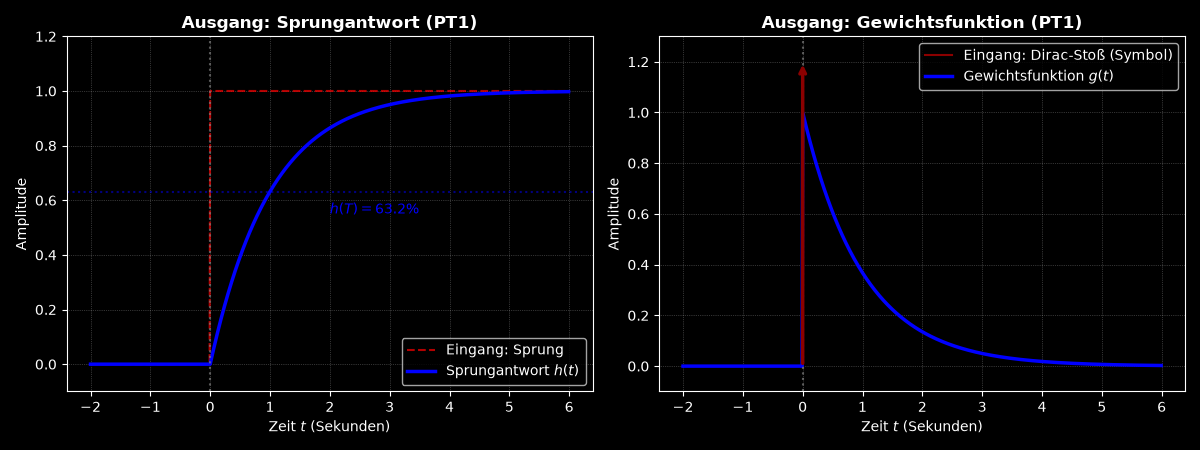

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Zeitachse definieren
dt = 0.01
t = np.arange(-2.0, 6.0, dt)

# 1. Einheitssprung u_sprung(t)
u_sprung = np.where(t >= 0, 1.0, 0.0)

# Systemparameter (PT1-Glied)
T = 1.0
K = 1.0

# Analystische/Exakte Lösungen für sauberen Plot & Simulation
# Sprungantwort: h(t) = K * (1 - exp(-t/T)) für t >= 0
y_sprung = np.where(t >= 0, K * (1.0 - np.exp(-t / T)), 0.0)

# Gewichtsfunktion (Impulsantwort): g(t) = (K/T) * exp(-t/T) für t >= 0
y_impuls = np.where(t >= 0, (K / T) * np.exp(-t / T), 0.0)

# --- Visualisierung ---
plt.style.use('dark_background') # Passend zu deinem Screenshot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Sprungantwort
ax1.plot(t, u_sprung, 'r--', alpha=0.7, label='Eingang: Sprung')
ax1.plot(t, y_sprung, 'b-', linewidth=2.5, label=r'Sprungantwort $h(t)$')
ax1.axvline(0, color='gray', linestyle=':', alpha=0.7)
ax1.axhline(K * 0.632, color='blue', linestyle=':', alpha=0.5)
ax1.text(2.0, 0.55, r'$h(T) = 63.2\%$', color='blue')
ax1.set_title('Ausgang: Sprungantwort (PT1)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Zeit $t$ (Sekunden)')
ax1.set_ylabel('Amplitude')
ax1.set_ylim(-0.1, 1.2)
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.legend(loc='lower right')

# Plot 2: Gewichtsfunktion (Impulsantwort)
ax2.annotate('', xy=(0, 1.2), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color='darkred', lw=2.5))
ax2.plot([], [], 'darkred', linestyle='-', label='Eingang: Dirac-Stoß (Symbol)')
ax2.plot(t, y_impuls, 'b-', linewidth=2.5, label=r'Gewichtsfunktion $g(t)$')
ax2.axvline(0, color='gray', linestyle=':', alpha=0.7)
ax2.set_title('Ausgang: Gewichtsfunktion (PT1)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Zeit $t$ (Sekunden)')
ax2.set_ylabel('Amplitude')
ax2.set_ylim(-0.1, 1.3)
ax2.grid(True, linestyle=':', alpha=0.4)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

###  Der PID-Regler

#### 1. Formel im Zeitbereich
$$u(t) = \underbrace{K_P \cdot e(t)}_{\text{P-Anteil}} + \underbrace{\frac{K_P}{T_N} \int_0^t e(\tau)\,\mathrm{d}\tau}_{\text{I-Anteil}} + \underbrace{K_P T_V \frac{\mathrm{d}e(t)}{\mathrm{d}t}}_{\text{D-Anteil}}$$


---

#### 2. Formel im Frequenzbereich


$$G_R(s) = \underbrace{K_P}_{\text{P-Anteil}} + \underbrace{\frac{K_P}{T_N s}}_{\text{I-Anteil}} + \underbrace{K_P T_V s}_{\text{D-Anteil}}$$

---

#### 3. Ordnung des Reglers

* **Wo liest man die Ordnung ab?**
  Die Ordnung $n$ eines LTI-Systems/Reglers liest man im Frequenzbereich am Grad des Nennerpolynoms der Übertragungsfunktion $G(s)$  ab (also an der höchsten Potenz von $s$ im Nenner). Alternativ entspricht sie der Anzahl der Systempole bzw. der Anzahl der Zustandsgrößen im Zustandsraum.


In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, Math
from scipy import signal

warnings.filterwarnings('ignore', category=BadCoefficients) if 'BadCoefficients' in globals() else warnings.filterwarnings('ignore')


def trim_zeros(poly):
    poly = np.trim_zeros(np.asarray(poly, dtype=float), trim='f')
    return poly if len(poly) > 0 else np.array([0.0])

dt = 0.01
t_pos = np.arange(0.0, 6.0, dt)
t_neg = np.arange(-2.0, 0.0, dt)
t = np.concatenate([t_neg, t_pos])
u_sprung = np.where(t >= 0, 1.0, 0.0)


def update_pid_ordnung(show_p, show_i, show_d, K_P, K_I, K_D, ordnung, T_sys):

    kp = K_P if show_p else 0.0
    ki = K_I if show_i else 0.0
    kd = K_D if show_d else 0.0

    #
    t2 = T_sys**2
    t2_dt = 2 * T_sys

    if ordnung == 0:
        num_sys = [1.0]
        den_sys = [1.0]
        nenner_str = "1"
        dgl_links = "y(t)"
    elif ordnung == 1:
        num_sys = [1.0]
        den_sys = [T_sys, 1.0]
        nenner_str = f"{T_sys:.1f}s + 1"
        dgl_links = f"{T_sys:.1f}\\dot{{y}}(t) + y(t)"
    elif ordnung == 2:
        num_sys = [1.0]
        den_sys = [t2, t2_dt, 1.0]
        nenner_str = f"{t2:.2f}s^2 + {t2_dt:.1f}s + 1"
        dgl_links = f"{t2:.2f}\\ddot{{y}}(t) + {t2_dt:.1f}\\dot{{y}}(t) + y(t)"

    kd_sim = 0.0 if ordnung == 0 else kd

    if ki == 0 and kd_sim == 0 and kp == 0:
        num_pid = [0.0]
        den_pid = [1.0]
    elif ki == 0 and kd_sim == 0:
        num_pid = [kp]
        den_pid = [1.0]
    elif ki == 0:
        num_pid = [kd_sim, kp]
        den_pid = [1.0]
    else:
        num_pid = [kd_sim, kp, ki]
        den_pid = [1.0, 0.0]

    num_pid = trim_zeros(num_pid)

    num_ges = np.convolve(num_pid, num_sys)
    den_ges = np.convolve(den_pid, den_sys)

    num_ges = trim_zeros(num_ges)
    den_ges = trim_zeros(den_ges)

    pid_terms = []
    if kp != 0: pid_terms.append(f"{kp:.1f}")
    if ki != 0: pid_terms.append(f"\\frac{{{ki:.1f}}}{{s}}")
    if kd != 0: pid_terms.append(f"{kd:.1f}s")
    pid_str = " + ".join(pid_terms) if pid_terms else "0"

    if ordnung == 0:
        g_s_str = pid_str
    else:
        g_s_str = f"\\left( {pid_str} \\right) \\cdot \\frac{{1}}{{{nenner_str}}}"

    dgl_rechts_terms = []
    if kp != 0: dgl_rechts_terms.append(f"{kp:.1f}u(t)")
    if ki != 0: dgl_rechts_terms.append(f"{ki:.1f} \\int_{{0}}^{{t}} u(\\tau) d\\tau")
    if kd != 0: dgl_rechts_terms.append(f"{kd:.1f}\\dot{{u}}(t)")
    dgl_rechts_str = " + ".join(dgl_rechts_terms) if dgl_rechts_terms else "0"

    display(Math(r"\textbf{Übertragungsfunktion:} \quad G(s) = " + g_s_str))
    display(Math(r"\textbf{Differentialgleichung:} \quad " + dgl_links + " = " + dgl_rechts_str))

    y_pos = np.zeros_like(t_pos)
    if np.any(num_ges) and not np.all(num_ges == 0):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sys = signal.TransferFunction(num_ges, den_ges)
            _, y_pos = signal.step(sys, T=t_pos)

    y_gesamt = np.concatenate([np.zeros_like(t_neg), y_pos])

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(t, u_sprung, 'r--', alpha=0.6, label='Eingang')
    ax.plot(t, y_gesamt, 'b-', linewidth=2.5, label='Ausgang')

    if kd != 0 and ordnung == 0:
        ax.annotate('', xy=(0, kp + 2.0), xytext=(0, kp),
                    arrowprops=dict(arrowstyle="->", color='darkblue', lw=2.5, ls=':'))
        ax.text(0.1, kp + 0.5, r'D-Stoß $\delta(t)$', color='darkblue', fontsize=10)

    ax.axvline(0, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(f'PID-Verhalten', fontsize=13, fontweight='bold')
    ax.set_xlabel('Zeit', fontsize=11)
    ax.set_ylabel('Amplitude', fontsize=11)

    ax.set_xlim(-2.0, 6.0)
    ax.set_ylim(-0.5, 5.5)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left', fontsize=10)

    plt.show()

style = {'description_width': 'initial'}

cb_p = widgets.Checkbox(value=True, description='P-Anteil aktivieren', style=style)
cb_i = widgets.Checkbox(value=False, description='I-Anteil aktivieren', style=style)
cb_d = widgets.Checkbox(value=False, description='D-Anteil aktivieren', style=style)

slider_kp = widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1, description='$K_P$:', continuous_update=True)
slider_ki = widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='$K_I$:', continuous_update=True)
slider_kd = widgets.FloatSlider(value=0.2, min=0.05, max=1.0, step=0.05, description='$K_D$:', continuous_update=True)

dropdown_ordnung = widgets.Dropdown(
    options=[('Ordnung n = 0 (Ideales Glied)', 0),
             ('Ordnung n = 1 (PT1-Glied)', 1),
             ('Ordnung n = 2 (PT2-Glied)', 2)],
    value=0,
    description='Systemordnung:',
    style=style
)

slider_tsys = widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='Zeitkonstante $T_{sys}$:', continuous_update=True)

controls_left = VBox([cb_p, slider_kp])
controls_center = VBox([cb_i, slider_ki])
controls_right = VBox([cb_d, slider_kd])
ui_pid = HBox([controls_left, controls_center, controls_right])

ui_system = HBox([dropdown_ordnung, slider_tsys])
ui_gesamt = VBox([ui_system, ui_pid])

out = widgets.interactive_output(update_pid_ordnung, {
    'show_p': cb_p, 'show_i': cb_i, 'show_d': cb_d,
    'K_P': slider_kp, 'K_I': slider_ki, 'K_D': slider_kd,
    'ordnung': dropdown_ordnung, 'T_sys': slider_tsys
})

display(ui_gesamt, out)

Output()

### Bleibende Regelabweichung ($e_{\infty}$)

Die bleibende Regelabweichung im stationären Zustand ($t \to \infty$) beschreibt die Differenz zwischen Führungsgröße $w(t)$ und Istwert $x(t)$ nach dem Einschwingvorgang.





In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox
from IPython.display import display, clear_output, Math, HTML
from scipy import signal

# Zeitachse & Eingangs- / Störsignale
dt = 0.01
t = np.arange(0.0, 30.0, dt)
w = np.ones_like(t)                   # Führungsgröße konstant auf w_0 = 1
z1 = np.zeros_like(t)                 # Störgröße dauerhaft auf 0

# Feste Zeitkonstanten für Regler und reine Strecke
T_STRECKE_FEST = 0.5
T_REGLER_FEST = 0.2

# Output-Widgets zur sauberen Aktualisierung
plot_output = widgets.Output()
math_output = widgets.Output()


def simulate_and_plot(change=None):
    Kp = s_kp.value
    Ki = s_ki.value

    # Berechnung des statischen Verstärkungsfaktors K_0 & e_infty
    if Ki == 0.0:
        K_0 = Kp * 1.0
        e_infty_val = 1.0 / (1.0 + K_0)
    else:
        K_0 = float('inf')
        e_infty_val = 0.0

    # System-Zähler/Nenner für den Regler definieren
    if Ki == 0.0 and Kp == 0.0:
        num_regler, den_regler = [0], [1]
    elif Ki == 0.0:
        num_regler, den_regler = [Kp], [T_REGLER_FEST, 1]
    else:
        num_regler, den_regler = [Kp, Ki], [T_REGLER_FEST, 1, 0]

    # Übertragungsfunktionen für Regler und reine Strecke
    G_regler = signal.TransferFunction(num_regler, den_regler)
    G_strecke = signal.TransferFunction([1], [T_STRECKE_FEST**2, 2 * T_STRECKE_FEST, 1])

    # Umwandlung in Zustandsraum für schrittweise Simulation
    sys_regler = G_regler.to_ss()
    sys_strecke = G_strecke.to_ss()

    x_regler = np.zeros(sys_regler.A.shape[0])
    x_strecke = np.zeros(sys_strecke.A.shape[0])

    e_plot = np.zeros_like(t)
    y = 0.0  # Direkte Rückführung des Ausgangssignals (ohne Sensor)

    # Simulation über die Zeitachse
    for i in range(len(t)):
        e = w[i] - y
        e_plot[i] = e

        # Regler-Dynamik
        dx_regler = sys_regler.A @ x_regler + sys_regler.B.flatten() * e
        x_regler += dx_regler * dt
        u = (sys_regler.C @ x_regler + sys_regler.D * e).item()

        # Strecken-Dynamik
        strecke_in = u + z1[i]
        dx_strecke = sys_strecke.A @ x_strecke + sys_strecke.B.flatten() * strecke_in
        x_strecke += dx_strecke * dt
        y = (sys_strecke.C @ x_strecke + sys_strecke.D * strecke_in).item()

    # --- Visualisierung ---
    with plot_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4.2))

        ax.plot(t, e_plot, label='Regelabweichung $e(t)$', color='firebrick', lw=2)

        ax.set_title('Regelabweichung', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Zeit', fontsize=10)
        ax.set_ylabel('Signalwert', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, 30)
        ax.set_ylim(-0.5, 1.5)
        ax.legend(loc='upper right')

        plt.tight_layout()
        plt.show()

    # --- Mathematische Erläuterung (Dunkelmodus-optimiert) ---
    with math_output:
        clear_output(wait=True)


        # Dynamische Generierung des Formelstrings für G_R(s)
        if Kp == 0.0 and Ki == 0.0:
            regler_str = "0"
        elif Ki == 0.0:
            regler_str = rf"\frac{{{Kp:.1f}}}{{{T_REGLER_FEST}s + 1}}"
        elif Kp == 0.0:
            regler_str = rf"\frac{{{Ki:.1f}}}{{s({T_REGLER_FEST}s + 1)}}"
        else:
            regler_str = rf"\frac{{{Kp:.1f}s + {Ki:.1f}}}{{s({T_REGLER_FEST}s + 1)}}"

        # Reine Strecke als Term (PT2)
        strecke_str = rf"\frac{{1}}{{({T_STRECKE_FEST}s + 1)^2}}"

        display(HTML("<b>Übertragungsfunktion der offenen Kette:</b>"))
        display(Math(rf"G_0(s) = G_R(s) \cdot G_S(s) = {regler_str} \cdot {strecke_str}"))
        display(HTML("<hr style='border: none; border-top: 1px solid #444; margin: 10px 0;'>"))

        display(HTML("</div>"))

# UI-Steuerelemente
style = {'description_width': 'initial'}

s_kp = widgets.FloatSlider(value=2.0, min=0.0, max=4.0, step=0.5, description='$K_P$ (Proportional):', style=style)
s_ki = widgets.FloatSlider(value=0.0, min=0.0, max=1.5, step=0.5, description='$K_I$ (Integral):', style=style)

for s in [s_kp, s_ki]:
    s.observe(simulate_and_plot, names='value')

ui = VBox([widgets.Label('Regler-Verstärkungen'), s_kp, s_ki])

display(ui, plot_output, math_output)
simulate_and_plot()

Output()

Output()

### Vorfilter

Eine bleibende Regelabweichung kann mithilfe eines Vorfilters eliminiert werden. Der Vorfilter ist hierbei eine einfache Verstärkung von $V_0 = \frac{1 + K_0}{K_0}$,
 welcher das Führungssignal vorab so hoch skaliert, sodass der Ausgang im stationären Zustand exakt den gewünschten Sollwert erreicht.


In [7]:
%matplotlib inline

import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import VBox
from IPython.display import display, clear_output

# 1. Zeitachse & Systemparameter (nur Regler & Strecke)
dt = 0.01
t = np.arange(0.0, 10.0, dt)
w = np.where(t >= 1.0, 1.0, 0.0)      # Führungssprung bei t = 1s

KP_FEST = 2.0       # P-Regler Verstärkung
T_STRECKE = 0.5     # Strecke Zeitkonstante (PT2-Glied)

# Statische Kreisverstärkung K0 für idealen Vorfilter V0_ideal = (1 + K0) / K0
K0 = KP_FEST
V0_IDEAL = (1.0 + K0) / K0  # = 1.50

# --- SYSTEMBERECHNUNG (ohne Aktor und Sensor) ---
num_R, den_R = [KP_FEST], [1]
num_S, den_S = [1], [T_STRECKE**2, 2*T_STRECKE, 1]

num_fwd = np.polymul(num_R, num_S)
den_fwd = np.polymul(den_R, den_S)

# Geschlossener Regelkreis: G_cl(s) = G_fwd(s) / (1 + G_fwd(s))
num_cl = num_fwd
den_cl = np.polyadd(den_fwd, num_fwd)

sys_cl = signal.TransferFunction(num_cl, den_cl)

# Basissantwort des geschlossenen Kreises für den ungefilterten Einheitssprung w(t)
_, y_base, _ = signal.lsim(sys_cl, U=w, T=t)

# Output-Widget zur Aktualisierung
plot_output = widgets.Output()

def simulate_and_plot(change=None):
    V0 = s_v0.value
    w_tilde = V0 * w
    y = V0 * y_base

    with plot_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 4.5))

        ax.plot(t, w, label='Sollwert $w(t)$', color='white', linestyle='--')
        ax.plot(t, w_tilde, label=r'Gefilterter Sollwert $\tilde{w}(t)$', color='#00FFCC', linestyle=':')
        ax.plot(t, y, label='Istwert $y(t)$', color='#3399FF', lw=2.5)

        ax.set_title(f'Systemantwort mit Vorfilter', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Zeit $t$ [s]', fontsize=10)
        ax.set_ylabel('Amplitude', fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.set_xlim(0, 10)
        ax.set_ylim(-0.1, 2.2)
        ax.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

# UI-Steuerelement (Slider)
style = {'description_width': 'initial'}
s_v0 = widgets.FloatSlider(value=1.00, min=0.50, max=2.00, step=0.05, description='$V_0$ (Vorfilter):', style=style)

s_v0.observe(simulate_and_plot, names='value')
ui = VBox([widgets.Label(''), s_v0])

display(ui, plot_output)
simulate_and_plot()

Output()

### Kenngrößen der Sprungantwort ($PT_2$-Verhalten)

Diese Kennwerte beschreiben, wie schnell und stabil das System auf einen Sprung reagiert:


In [9]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout
from IPython.display import display, Math, clear_output

# 1. Zeitachse auf 20s definieren
t_max = 20.0
t = np.linspace(0, t_max, 2000)

# 2. Mathematische Berechnungsfunktion
def calc_pt2_kenngroessen(D, T0, K):
    w0 = 1.0 / T0
    wd = w0 * np.sqrt(1.0 - D**2)
    phi = np.arccos(D)

    # Analytische Lösung h(t)
    h = K * (1.0 - (np.exp(-D * w0 * t) / np.sqrt(1.0 - D**2)) * np.sin(wd * t + phi))

    # --- Kenngrößen ---
    delta_h_rel = np.exp(-np.pi * D / np.sqrt(1.0 - D**2))
    delta_h_abs = K * delta_h_rel
    Tm = np.pi / wd
    h_max = K + delta_h_abs

    # Anregelzeit Tan
    Tan = (np.pi - phi) / wd

    # Anstiegszeit Trise (10% bis 90%)
    idx_10 = np.argmax(h >= 0.1 * K)
    idx_90 = np.argmax(h >= 0.9 * K)
    t_10, t_90 = t[idx_10], t[idx_90]
    Trise = t_90 - t_10

    # Ausregelzeit T5%
    dev = np.abs(h - K) / K
    outside_5 = np.where(dev > 0.05)[0]
    T5 = t[outside_5[-1]] if len(outside_5) > 0 else 0.0

    return h, Tm, h_max, Tan, T5, t_10, t_90, K, delta_h_rel, delta_h_abs, Trise

# Startwerte
D_init, T0_init, K_init = 0.3, 1.0, 1.0
h_i, Tm_i, hmax_i, Tan_i, T5_i, t10_i, t90_i, K_i, dh_rel_i, dh_abs_i, Trise_i = calc_pt2_kenngroessen(D_init, T0_init, K_init)

# 3. FigureWidget (Plotly)
fig = go.FigureWidget()

# Trace 0: Sprungantwort h(t)
fig.add_trace(go.Scatter(
    x=t, y=h_i, mode='lines',
    name='Sprungantwort h(t)',
    line=dict(color='#00FFCC', width=3)
))

# Trace 1: Statischer Endwert
fig.add_trace(go.Scatter(
    x=[0, t_max], y=[K_i, K_i],
    mode='lines',
    name='Statischer Endwert',
    line=dict(color='white', dash='dash', width=1.5)
))

# Trace 2: 5%-Toleranzband
fig.add_trace(go.Scatter(
    x=[0, t_max, None, 0, t_max],
    y=[K_i*1.05, K_i*1.05, None, K_i*0.95, K_i*0.95],
    mode='lines',
    name='5%-Toleranzband',
    line=dict(color='rgba(255, 255, 255, 0.3)', dash='dot')
))

# Trace 3: Überschwingweite (Differenz Peak zu Statischer Endwert bei Tm)
fig.add_trace(go.Scatter(
    x=[Tm_i, Tm_i], y=[K_i, hmax_i],
    mode='lines+markers',
    name='Überschwingweite Δh',
    line=dict(color='#FF5555', width=2.5),
    marker=dict(size=8, symbol='circle')
))

# Trace 4: Anregelzeit
fig.add_trace(go.Scatter(
    x=[Tan_i, Tan_i], y=[0, K_i],
    mode='lines+markers',
    name='Anregelzeit',
    line=dict(color='#FFAA00', dash='dash'),
    marker=dict(size=8, symbol='circle')
))

# Trace 5: Ausregelzeit 5%
fig.add_trace(go.Scatter(
    x=[T5_i, T5_i], y=[0, K_i*1.05],
    mode='lines+markers',
    name='Ausregelzeit 5 %',
    line=dict(color='#AA55FF', dash='dash'),
    marker=dict(size=8, symbol='circle')
))

# Trace 6: Anstiegszeit
fig.add_trace(go.Scatter(
    x=[t10_i, t90_i], y=[K_i*0.1, K_i*0.9],
    mode='lines+markers',
    name='Anstiegszeit',
    line=dict(color='#00AAFF', width=2.5),
    marker=dict(size=8, symbol='circle')
))

fig.update_layout(
    title="Kenngrößen der Übergangsantwort an einem PT₂-Glied",
    template="plotly_dark",
    paper_bgcolor='#121212',
    plot_bgcolor='#181818',
    height=500,
    margin=dict(t=50, b=40, l=50, r=40),
    xaxis=dict(title="Zeit t [s]", range=[0, t_max], gridcolor='#333333'),
    yaxis=dict(title="Amplitude h(t)", range=[-0.1, 2.3], gridcolor='#333333'),
    legend=dict(x=0.70, y=0.98, bgcolor="rgba(25, 25, 25, 0.8)")
)

# 4. UI Steuerungselemente
style = {'description_width': 'initial'}

slider_d = widgets.FloatSlider(value=0.3, min=0.05, max=0.95, step=0.01, description='Dämpfung D:', style=style, layout=Layout(width='280px'))
slider_t0 = widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description='Zeitkonstante T0:', style=style, layout=Layout(width='280px'))
slider_k = widgets.FloatSlider(value=1.0, min=0.5, max=2.0, step=0.1, description='Verstärkung K:', style=style, layout=Layout(width='280px'))

# Output-Widget für perfektes LaTeX-Rendering
out_math = widgets.Output()

# 5. Update-Logik
def update(D, T0, K):
    h, Tm, hmax, Tan, T5, t10, t90, K_val, dh_rel, dh_abs, Trise = calc_pt2_kenngroessen(D, T0, K)

    # Formeln mit MathJax neu rendern
    with out_math:
        clear_output(wait=True)
        display(Math(f"\\textbf{{Übertragungsfunktion:}} \\quad G(s) = \\frac{{{K:.2f}}}{{{T0**2:.2f}s^2 + {2*D*T0:.2f}s + 1}} \\quad | \\quad \\textbf{{DGL:}} \\quad {T0**2:.2f}\\ddot{{y}}(t) + {2*D*T0:.2f}\\dot{{y}}(t) + y(t) = {K:.2f}u(t)"))
        display(Math(f"\\textbf{{Kenngrößen:}} \\quad \\Delta h: {dh_rel*100:.1f}\\% \\, ({dh_abs:.2f}) \\quad | \\quad T_m: {Tm:.2f}\\text{{ s}} \\quad | \\quad T_{{an}}: {Tan:.2f}\\text{{ s}} \\quad | \\quad T_{{rise}}: {Trise:.2f}\\text{{ s}} \\quad | \\quad T_{{5\\%}}: {T5:.2f}\\text{{ s}}"))

    with fig.batch_update():
        fig.data[0].y = h
        fig.data[1].x = [0, t_max]
        fig.data[1].y = [K_val, K_val]

        # 5%-Band
        fig.data[2].x = [0, t_max, None, 0, t_max]
        fig.data[2].y = [K_val*1.05, K_val*1.05, None, K_val*0.95, K_val*0.95]

        # Überschwingweite Δh (vom Endwert K_val bis zum Peak hmax)
        fig.data[3].x = [Tm, Tm]
        fig.data[3].y = [K_val, hmax]

        # Anregelzeit
        fig.data[4].x = [Tan, Tan]
        fig.data[4].y = [0, K_val]

        # Ausregelzeit 5%
        fig.data[5].x = [T5, T5]
        fig.data[5].y = [0, K_val*1.05]

        # Anstiegszeit
        fig.data[6].x = [t10, t90]
        fig.data[6].y = [K_val*0.1, K_val*0.9]

out_interactive = widgets.interactive_output(update, {'D': slider_d, 'T0': slider_t0, 'K': slider_k})

# 6. Anzeige aufbauen
controls_params = HBox([slider_d, slider_t0, slider_k])
ui_layout = VBox([controls_params, out_math, fig])

display(ui_layout)

### Zusammenhang der Lage der Polstellen mit der geschlossenen PT2-RK Übergangfunktion

Wie bewegen sich die Pole, wenn man die Dämpfung und die Zeitkonstante verändert?


In [18]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout
from IPython.display import display, Math, clear_output

# 1. FigureWidget für die komplexe s-Ebene initialisieren
fig_s = go.FigureWidget()

# Initialwerte
D_init = 0.3
T_init = 1.0

# --- Traces anlegen ---

# Trace 0: Polbahn / Ortskurve für variierendes D (Halbkreis mit Radius w0 = 1/T)
fig_s.add_trace(go.Scatter(
    x=[], y=[], mode='lines',
    name='Polbahn',
    showlegend=False,
    line=dict(color='rgba(255, 255, 255, 0.25)', dash='dash', width=1.5)
))

# Trace 1: Achsenkreuz (Re=0, Im=0)
fig_s.add_trace(go.Scatter(
    x=[-3, 1, None, 0, 0], y=[0, 0, None, -2.5, 2.5],
    mode='lines',
    showlegend=False,
    line=dict(color='#555555', width=1)
))

# Trace 2: Zeiger vom Ursprung zu s1 (Radius w0)
fig_s.add_trace(go.Scatter(
    x=[], y=[], mode='lines',
    name='Radius',
    showlegend=True,
    line=dict(color='#FFAA00', width=2)
))

# Trace 3: Hilfslinien für Real- (-delta_e) und Imaginärteil (+/- w_e)
fig_s.add_trace(go.Scatter(
    x=[], y=[], mode='lines',
    showlegend=False,
    line=dict(color='rgba(0, 255, 204, 0.5)', dash='dot', width=1.5)
))

# Trace 4: Polstelle s1 (konjugiert komplex positiv)
fig_s.add_trace(go.Scatter(
    x=[], y=[], mode='markers+text',
    name='Pol s1',
    showlegend=True,
    marker=dict(symbol='x', size=14, color='#FF5555', line=dict(width=3)),
    text=["s1"], textposition="top left",
    textfont=dict(color='#FF5555', size=14)
))

# Trace 5: Polstelle s2 (konjugiert komplex negativ)
fig_s.add_trace(go.Scatter(
    x=[], y=[], mode='markers+text',
    name='Pol s2',
    showlegend=True,
    marker=dict(symbol='x', size=14, color='#00AAFF', line=dict(width=3)),
    text=["s2"], textposition="bottom left",
    textfont=dict(color='#00AAFF', size=14)
))

# Layout der s-Ebene
fig_s.update_layout(
    title="Polstellenverlauf",
    template="plotly_dark",
    paper_bgcolor='#121212',
    plot_bgcolor='#181818',
    height=550,
    width=650,
    margin=dict(t=50, b=40, l=50, r=40),
    xaxis=dict(
        title="Realteil",
        range=[-2.2, 0.5],
        gridcolor='#333333',
        zeroline=True, zerolinecolor='#666666'
    ),
    yaxis=dict(
        title="Imaginärteil",
        range=[-1.8, 1.8],
        gridcolor='#333333',
        scaleanchor="x", scaleratio=1, # 1:1 Skalierung für echte Kreise
        zeroline=True, zerolinecolor='#666666'
    ),
    legend=dict(x=0.02, y=0.98, bgcolor="rgba(25, 25, 25, 0.8)")
)

# 2. Steuerungselemente (Sliders)
style = {'description_width': 'initial'}
slider_d = widgets.FloatSlider(value=D_init, min=0.01, max=0.99, step=0.01, description='Dämpfung D:', style=style, layout=Layout(width='300px'))
slider_t = widgets.FloatSlider(value=T_init, min=0.6, max=2.0, step=0.05, description='Zeitkonstante T:', style=style, layout=Layout(width='300px'))

out_math = widgets.Output()

# 3. Update-Funktion
def update_s_plane(D, T):
    w0 = 1.0 / T
    delta_e = D / T
    w_e = (np.sqrt(1.0 - D**2)) / T
    phi_deg = np.degrees(np.arccos(D))

    # Halbkreis für Polbahn bei konstantem w0
    angles = np.linspace(np.pi/2, 3*np.pi/2, 200)
    arc_x = -w0 * np.sin(angles - np.pi/2)
    arc_y = w0 * np.cos(angles - np.pi/2)

    # Formelausgabe
    with out_math:
        clear_output(wait=True)
        display(Math(f"s_{{1,2}} = -\\delta_e \\pm j\\omega_e = -{delta_e:.2f} \\pm j{w_e:.2f} \\text{{ s}}^{{-1}}"))
        display(Math(f"\\delta_e = \\frac{{D}}{{T}} = {delta_e:.2f} \\quad | \\quad \\omega_e = \\frac{{\\sqrt{{1-D^2}}}}{{T}} = {w_e:.2f} \\quad | \\quad \\omega_0 = \\frac{{1}}{{T}} = {w0:.2f} \\quad | \\quad \\varphi = {phi_deg:.1f}^\\circ"))

    with fig_s.batch_update():
        # Trace 0: Ortskurve
        fig_s.data[0].x = arc_x
        fig_s.data[0].y = arc_y

        # Trace 2: Zeiger vom Ursprung zu s1
        fig_s.data[2].x = [0, -delta_e]
        fig_s.data[2].y = [0, w_e]

        # Trace 3: gestrichelte Hilfslinien zu den Achsen
        fig_s.data[3].x = [-delta_e, -delta_e, None, -delta_e, 0, None, -delta_e, 0]
        fig_s.data[3].y = [-w_e, w_e, None, w_e, w_e, None, -w_e, -w_e]

        # Trace 4 & 5: Pole s1 und s2
        fig_s.data[4].x = [-delta_e]
        fig_s.data[4].y = [w_e]

        fig_s.data[5].x = [-delta_e]
        fig_s.data[5].y = [-w_e]

out_interactive = widgets.interactive_output(update_s_plane, {'D': slider_d, 'T': slider_t})

# 4. Layout anzeigen
controls = HBox([slider_d, slider_t])
ui_layout = VBox([controls, out_math, fig_s])

display(ui_layout)

### Bode- Diagramm

Das Bode Diagramm ist ein wichtiges Hilfsmittel zur Visualisierung von Funktionen im Frequenzbereich.
Welche Einflüsse haben die Verschiedenen Knickfrequenzen auf Phase und Amplitude?
Was passiert wenn man nur einen P I oder D anteil einstellt?



In [19]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout
from IPython.display import display, Math, clear_output
from scipy import signal

# 1. Dynamische Funktion zur Berechnung des Bode-Diagramms und der Frequenzachse
def get_transfer_function(K, T1, T2, T3, TI, TD):
    num = [K]
    den = [1.0]

    if TD > 0:
        num = np.convolve(num, [TD, 1.0])
    if TI > 0:
        den = np.convolve(den, [TI, 0.0])
    if T1 > 0:
        den = np.convolve(den, [T1, 1.0])
    if T2 > 0:
        den = np.convolve(den, [T2, 1.0])
    if T3 > 0:
        den = np.convolve(den, [T3, 1.0])

    # Aktive Knickfrequenzen ermitteln, um w dynamisch anzupassen
    freqs = []
    if T1 > 0: freqs.append(1.0 / T1)
    if T2 > 0: freqs.append(1.0 / T2)
    if T3 > 0: freqs.append(1.0 / T3)
    if TI > 0: freqs.append(1.0 / TI)
    if TD > 0: freqs.append(1.0 / TD)

    if freqs:
        min_w = min(freqs) / 10.0
        max_w = max(freqs) * 10.0
    else:
        min_w, max_w = 0.01, 100.0

    # Frequenzachse dynamisch erzeugen (mindestens 2 Dekaden Umkreis)
    w = np.logspace(np.log10(min_w), np.log10(max_w), 2000)

    system = signal.TransferFunction(num, den)
    _, mag, phase = signal.bode(system, w)

    return w, mag, phase

# 2. FigureWidget für das Bode-Diagramm
fig_bode = go.FigureWidget(make_subplots(
    rows=2, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.1,
    subplot_titles=("Amplitudengang |G(jω)|", "Phasengang arg(G(jω))")
))

# Traces 0 & 1: Amplituden- und Phasengang
fig_bode.add_trace(go.Scatter(
    x=[], y=[], mode='lines',
    name='Betrag [dB]', line=dict(color='#00FFCC', width=2.5)
), row=1, col=1)

fig_bode.add_trace(go.Scatter(
    x=[], y=[], mode='lines',
    name='Phase [°]', line=dict(color='#FFAA00', width=2.5)
), row=2, col=1)

# Traces 2 & 3: Marker EXAKT auf den Kurven
fig_bode.add_trace(go.Scatter(
    x=[], y=[], mode='markers+text', name='Knickfrequenzen (|G|)',
    marker=dict(size=10, color='#FF5555', symbol='diamond', line=dict(width=1, color='white')),
    text=[], textposition="top right",
    textfont=dict(color='#FF5555', size=11)
), row=1, col=1)

fig_bode.add_trace(go.Scatter(
    x=[], y=[], mode='markers+text', name='Knickfrequenzen (Phase)',
    marker=dict(size=10, color='#FF5555', symbol='diamond', line=dict(width=1, color='white')),
    text=[], textposition="bottom right",
    textfont=dict(color='#FF5555', size=11)
), row=2, col=1)

# Layout einstellen
fig_bode.update_layout(
    template="plotly_dark",
    paper_bgcolor='#121212',
    plot_bgcolor='#181818',
    height=580,
    margin=dict(t=50, b=40, l=60, r=40),
    showlegend=False
)

fig_bode.update_xaxes(type="log", title_text="Kreisfrequenz ω [rad/s]", gridcolor='#333333', row=2, col=1)
fig_bode.update_xaxes(type="log", gridcolor='#333333', row=1, col=1)

fig_bode.update_yaxes(title_text="Verstärkung [dB]", gridcolor='#333333', row=1, col=1)
fig_bode.update_yaxes(title_text="Phase [°]", gridcolor='#333333', row=2, col=1)

# 3. Steuerungselemente (Sliders)
style = {'description_width': 'initial'}
slider_layout = Layout(width='260px')

slider_k  = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Verstärkung K:', style=style, layout=slider_layout)
slider_t1 = widgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1, description='PT1 Zeit T1:', style=style, layout=slider_layout)
slider_t2 = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='PT2 Zeit T2:', style=style, layout=slider_layout)
slider_t3 = widgets.FloatSlider(value=0.1, min=0.0, max=0.5, step=0.01, description='PT3 Zeit T3:', style=style, layout=slider_layout)

slider_ti = widgets.FloatSlider(value=0.0, min=0.0, max=10.0, step=0.1, description='I-Anteil TI (0=aus):', style=style, layout=slider_layout)
slider_td = widgets.FloatSlider(value=0.0, min=0.0, max=10.0, step=0.1, description='D-Anteil TD (0=aus):', style=style, layout=slider_layout)

out_math = widgets.Output()

# 4. Update-Funktion
def update_bode(K, T1, T2, T3, TI, TD):
    w, mag, phase = get_transfer_function(K, T1, T2, T3, TI, TD)

    corner_freqs = []
    labels = []

    if T1 > 0: corner_freqs.append(1.0 / T1); labels.append("ω1 = 1/T1")
    if T2 > 0: corner_freqs.append(1.0 / T2); labels.append("ω2 = 1/T2")
    if T3 > 0: corner_freqs.append(1.0 / T3); labels.append("ω3 = 1/T3")
    if TI > 0: corner_freqs.append(1.0 / TI); labels.append("ωI = 1/TI")
    if TD > 0: corner_freqs.append(1.0 / TD); labels.append("ωD = 1/TD")

    # Exakte Interpolation aus den berechneten Bode-Werten
    mag_corners = []
    phase_corners = []
    log_w = np.log10(w)

    for wc in corner_freqs:
        log_wc = np.log10(wc)
        mag_corners.append(np.interp(log_wc, log_w, mag))
        phase_corners.append(np.interp(log_wc, log_w, phase))

    # Dynamic LaTeX Output
    num_str = f"{K:.1f}"
    if TD > 0: num_str += f" \\cdot ({TD:.1f}s + 1)"

    den_terms = []
    if TI > 0: den_terms.append(f"({TI:.1f}s)")
    if T1 > 0: den_terms.append(f"({T1:.1f}s + 1)")
    if T2 > 0: den_terms.append(f"({T2:.1f}s + 1)")
    if T3 > 0: den_terms.append(f"({T3:.1f}s + 1)")
    den_str = " \\cdot ".join(den_terms) if den_terms else "1"

    with out_math:
        clear_output(wait=True)
        display(Math(f"\\textbf{{Übertragungsfunktion:}} \\quad G(s) = \\frac{{{num_str}}}{{{den_str}}}"))

    # Plot-Daten in einem Batch aktualisieren
    with fig_bode.batch_update():
        # X- und Y-Daten der Frequenzgänge setzen
        fig_bode.data[0].x, fig_bode.data[0].y = w, mag
        fig_bode.data[1].x, fig_bode.data[1].y = w, phase

        # Marker auf die Kurven setzen
        fig_bode.data[2].x, fig_bode.data[2].y = corner_freqs, mag_corners
        fig_bode.data[2].text = labels

        fig_bode.data[3].x, fig_bode.data[3].y = corner_freqs, phase_corners
        fig_bode.data[3].text = labels

out_interactive = widgets.interactive_output(
    update_bode,
    {'K': slider_k, 'T1': slider_t1, 'T2': slider_t2, 'T3': slider_t3, 'TI': slider_ti, 'TD': slider_td}
)

# 5. UI-Layout
controls_pt = VBox([slider_k, slider_t1, slider_t2, slider_t3])
controls_id = VBox([slider_ti, slider_td])
all_controls = HBox([controls_pt, controls_id], layout=Layout(justify_content='flex-start', grid_gap='20px'))

ui_layout = VBox([all_controls, out_math, fig_bode])

display(ui_layout)

### Phasenrand ($\Phi_R$) und Amplitudenreserve ($A_R$)

#### 1. Phasenrand (Phasenreserve)
Um den Phasenrand abzulesen, wird zunächst die **Schnittfrequenz** $\omega_s$ bestimmt. Das ist die Frequenz, bei der der Betrag der Verstärkung gleich $1$ (bzw. $0\text{ dB}$) ist:
$$|G(j\omega_s)| = 1 \quad \text{bzw.} \quad |G(j\omega_s)|_{\text{dB}} = 0\text{ dB}$$

An dieser Stelle liest man im Phasendiagramm den Phasenwinkel $\varphi(\omega_s)$ ab. Der Phasenrand errechnet sich aus der Differenz zu $-180^\circ$:

$$\Phi_R = \varphi(\omega_s) - (-180^\circ) = \varphi(\omega_s) + 180^\circ$$

---

#### 2. Amplitudenreserve (Amplitudenrand)
Um die Amplitudenreserve zu bestimmen, wird die **Phasendurchgangsfrequenz** $\omega_{180}$ ermittelt. Das ist die Frequenz, bei der die Phase genau $-180^\circ$ beträgt:
$$\varphi(\omega_{180}) = -180^\circ$$

An dieser Stelle liest man im Amplitudendiagramm den Betrag ab. Die Amplitudenreserve ist der Abstand von der $0\text{ dB}$-Linie zur Amplitudenkurve:

$$A_R = 0\text{ dB} - |G(j\omega_{180})|_{\text{dB}} = -|G(j\omega_{180})|_{\text{dB}}$$


In [29]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from ipywidgets import VBox, Layout
from IPython.display import display, Math, clear_output
from scipy import signal

# --- 1. Feste Parameter (T1, T2, T3) ---
T1 = 4.0
T2 = 3.0
T3 = 2.0

# --- 2. Systemanalyse-Funktion ---
def analyze_system(K):
    num = [K]
    den = [1.0]
    if T1 > 0: den = np.convolve(den, [T1, 1.0])
    if T2 > 0: den = np.convolve(den, [T2, 1.0])
    if T3 > 0: den = np.convolve(den, [T3, 1.0])

    sys = signal.TransferFunction(num, den)

    # Frequenzachse berechnen
    freqs = [1/t for t in [T1, T2, T3] if t > 0]
    min_w = min(freqs) / 5.0
    max_w = max(freqs) * 20.0
    w = np.logspace(np.log10(min_w), np.log10(max_w), 3000)

    w_out, mag_db, phase_deg = signal.bode(sys, w)
    _, resp = signal.freqresp(sys, w)

    # Schnittfrequenzen bestimmen
    idx_ws = np.argmin(np.abs(mag_db))
    w_s = w[idx_ws]
    phase_at_ws = phase_deg[idx_ws]
    pm = 180.0 + phase_at_ws

    idx_w1 = np.argmin(np.abs(phase_deg - (-180.0)))
    w_1 = w[idx_w1]
    mag_at_w1 = mag_db[idx_w1]
    gm_db = -mag_at_w1
    gm_abs = 10**(-mag_at_w1 / 20.0)

    return w, mag_db, phase_deg, resp, w_s, phase_at_ws, pm, w_1, mag_at_w1, gm_db, gm_abs, idx_ws, idx_w1

# --- 3. Plotly Figure Widget Setup ---
fig = go.FigureWidget(make_subplots(
    rows=2, cols=2,
    specs=[[{"rowspan": 2}, {"type": "xy"}],
           [None,            {"type": "xy"}]],
    subplot_titles=("Ortskurve", "Amplitudengang", "Phasengang"),
    horizontal_spacing=0.12,
    vertical_spacing=0.12
))

# --- Ortskurve (Spalte 1) ---
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', name='G₀(jω)', line=dict(color='#00FFCC', width=2.5)), row=1, col=1)

th = np.linspace(0, 2*np.pi, 200)
# showlegend=False für Einheitskreis
fig.add_trace(go.Scatter(x=np.cos(th), y=np.sin(th), mode='lines', name='Einheitskreis', showlegend=False, line=dict(color='#555555', dash='dash', width=1)), row=1, col=1)
# showlegend=False für Kritischer Punkt
fig.add_trace(go.Scatter(x=[-1], y=[0], mode='markers', name='Krit. Punkt (-1,0)', showlegend=False, marker=dict(color='red', size=8, symbol='x')), row=1, col=1)

fig.add_trace(go.Scatter(x=[], y=[], mode='markers+lines', name='Phasenreserve (Ø_R)', marker=dict(color='#FFAA00', size=8), line=dict(color='#FFAA00', dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=[], y=[], mode='markers+lines', name='Amplitudenreserve (A_R)', marker=dict(color='#FF5555', size=8), line=dict(color='#FF5555', dash='dot')), row=1, col=1)

# --- Bode Amplitudengang (Zeile 1, Spalte 2) ---
# showlegend=False für Betrag
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', name='Betrag [dB]', showlegend=False, line=dict(color='#00FFCC', width=2)), row=1, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#888888', dash='dash', width=1), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#FFAA00', dash='dot', width=1.5), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers+text', name='A_R', line=dict(color='#FF5555', width=3), marker=dict(size=6, color='#FF5555'), text=[], textposition="middle right", textfont=dict(color='#FF5555', size=12)), row=1, col=2)

# --- Bode Phasengang (Zeile 2, Spalte 2) ---
# showlegend=False für Phase
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', name='Phase [°]', showlegend=False, line=dict(color='#00FFCC', width=2)), row=2, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#888888', dash='dash', width=1), showlegend=False), row=2, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers+text', name='Ø_R', line=dict(color='#FFAA00', width=3), marker=dict(size=6, color='#FFAA00'), text=[], textposition="middle right", textfont=dict(color='#FFAA00', size=12)), row=2, col=2)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#FF5555', dash='dot', width=1.5), showlegend=False), row=2, col=2)

# --- Achsen-Styling & Limits ---
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor='#121212',
    plot_bgcolor='#181818',
    height=600,
    margin=dict(t=50, b=40, l=60, r=40),
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="left", x=0)
)

# 1. Skalierung Nyquist auf [-3, 3] für Re und Im
fig.update_xaxes(title_text="Realteil Re{G₀}", range=[-3, 3], gridcolor='#333333', row=1, col=1)
fig.update_yaxes(title_text="Imaginärteil Im{G₀}", range=[-3, 3], gridcolor='#333333', scaleanchor="x", scaleratio=1, row=1, col=1)

# 2. Bode Amplitudengang Achsen
fig.update_xaxes(type="log", gridcolor='#333333', row=1, col=2)
fig.update_yaxes(title_text="Betrag [dB]", gridcolor='#333333', row=1, col=2)

# 3. Bode Phasengang Achsen (mit exakter -180° Skala)
fig.update_xaxes(type="log", title_text="ω", gridcolor='#333333', row=2, col=2)
fig.update_yaxes(
    title_text="Phase [°]",
    gridcolor='#333333',
    tickmode='array',
    tickvals=[0, -45, -90, -135, -180, -225, -270],
    ticktext=['0°', '-45°', '-90°', '-135°', '-180°', '-225°', '-270°'],
    row=2, col=2
)

# --- 4. Interactive Slider & Update Logik ---
slider_k = widgets.FloatSlider(
    value=3.0, min=0.1, max=6.0, step=0.1,
    description='Verstärkung K:',
    style={'description_width': 'initial'},
    layout=Layout(width='500px')
)

out_info = widgets.Output()

def update_plots(K):
    w, mag_db, phase_deg, resp, w_s, phase_at_ws, pm, w_1, mag_at_w1, gm_db, gm_abs, idx_ws, idx_w1 = analyze_system(K)

    with out_info:
        clear_output(wait=True)


    with fig.batch_update():
        # Ortskurve
        fig.data[0].x, fig.data[0].y = resp.real, resp.imag
        pt_ws = resp[idx_ws]
        fig.data[3].x, fig.data[3].y = [0, pt_ws.real], [0, pt_ws.imag]
        pt_w1 = resp[idx_w1]
        fig.data[4].x, fig.data[4].y = [pt_w1.real, 0], [0, 0]

        # Bode Amplitudengang
        fig.data[5].x, fig.data[5].y = w, mag_db
        fig.data[6].x, fig.data[6].y = [w[0], w[-1]], [0, 0]
        fig.data[7].x, fig.data[7].y = [w_s, w_s], [0, phase_at_ws]
        fig.data[8].x, fig.data[8].y = [w_1, w_1], [mag_at_w1, 0.0]
        fig.data[8].text = ["", f"  A_R = {gm_db:.1f} dB"]

        # Bode Phasengang
        fig.data[9].x, fig.data[9].y = w, phase_deg
        fig.data[10].x, fig.data[10].y = [w[0], w[-1]], [-180, -180]
        fig.data[11].x, fig.data[11].y = [w_s, w_s], [phase_at_ws, -180.0]
        fig.data[11].text = ["", f"  Φ_R = {pm:.1f}°"]
        fig.data[12].x, fig.data[12].y = [w_1, w_1], [-180.0, mag_at_w1]

out_interactive = widgets.interactive_output(update_plots, {'K': slider_k})

# --- 5. Anzeige ---
display(VBox([slider_k, out_info, fig]))

### Gleichgewichtstheorem

Für ein stabiles Übertragungsverhalten $G_0(s)$ einer offenen Schleife mit einem relativen Grad $r > 1$ (Polüberschuss von mindestens 2) und einen stabilen Regelkreis gilt:

$$\int_{0}^{\infty} \ln |R(j\omega)| \, \mathrm{d}\omega = 0$$




In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import simpson
import ipywidgets as widgets
from ipywidgets import interact

def plot_betrag_empfindlichkeit(K=10.0):
    max_w = 40

    # 1. Definieren des offenen Regelkreises L(s) = K / (s^2 + 3s + 2)
    num_L = [K]
    den_L = [1, 3, 2]

    # 2. Empfindlichkeitsfunktion S(s) = 1 / (1 + L(s))
    num_S = den_L
    den_S = [den_L[0], den_L[1], den_L[2] + K]

    S = signal.TransferFunction(num_S, den_S)

    # 3. Frequenzvektor
    omega = np.linspace(0.001, max_w, 50000)
    _, mag_S_dB, _ = signal.bode(S, w=omega)

    mag_S = 10 ** (mag_S_dB / 20)
    ln_S = np.log(mag_S)

    # 4. Flächenberechnungen
    gegen_mask = ln_S < 0
    mit_mask = ln_S > 0

    # Gegenkopplung (vollständig im Bereich w < 40)
    area_gegen_gesamt = simpson(ln_S[gegen_mask], x=omega[gegen_mask]) if np.any(gegen_mask) else 0

    # Mitkopplung: Numerisches Integral (0 bis 40) + Asymptotisches Tail-Integral (40 bis infinity)
    area_mit_numerisch = simpson(ln_S[mit_mask], x=omega[mit_mask]) if np.any(mit_mask) else 0
    tail_mit = K / max_w
    area_mit_gesamt = area_mit_numerisch + tail_mit

    # 5. Visualisierung
    plt.figure(figsize=(10, 6))
    plt.style.use('dark_background')

    plt.plot(omega, ln_S, 'b-', linewidth=2)
    plt.axhline(0, color='white', linestyle='--', linewidth=1)

    plt.fill_between(omega, ln_S, 0, where=(ln_S < 0), color='green', alpha=0.4)
    plt.fill_between(omega, ln_S, 0, where=(ln_S > 0), color='red', alpha=0.4)

    plt.xlim([0, max_w])
    plt.ylim([min(ln_S) * 1.1, max(ln_S) * 1.15])

    plt.xlabel(r' $\omega$ ', fontsize=12)
    plt.ylabel(r'$|S(j\omega)|$', fontsize=12)
    plt.title('Gleichgewichtstheorem', fontsize=14, pad=10)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.tight_layout()

    plt.show()

    print(f"Gesamtintegral Gegenkopplung: {area_gegen_gesamt:.4f}")
    print(f"Gesamtintegral Mitkopplung  : {area_mit_gesamt:.4f}")
    print(f"Summe                       : {area_gegen_gesamt + area_mit_gesamt:.4f}")

# Interaktiver Schieberegler
style = {'description_width': 'initial'}
interact(
    plot_betrag_empfindlichkeit,
    K=widgets.FloatSlider(value=10.0, min=0.5, max=50.0, step=0.5, description='Verstärkung K:', style=style)
);

interactive(children=(FloatSlider(value=10.0, description='Verstärkung K:', max=50.0, min=0.5, step=0.5, style…

### Verhalten im Zeitbereich bei Verschiebung der Pole

Wie vehält sich die Impulsanwort, wenn die Pole komplex konjoguiert sind?
Ab wann wird das System instabil und wie ist das Grenzverhalten?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, Math

def plot_pole_and_response(sigma=-0.26, omega=0.965):
    # Zeitvektor für die Impulsantwort h(t) von 0 bis 15 s
    t = np.linspace(0, 15, 1000)

    # 1. Impulsantwort h(t) und Formelparameter berechnen
    if omega == 0:
        # Rein reeller Pol s = sigma
        h_t = np.exp(sigma * t)
        pole_label = fr"$s = {sigma:.2f}$"

        a0 = -sigma
        sign0 = '+' if a0 >= 0 else '-'

        den_tex = fr"1.00s {sign0} {abs(a0):.2f}"
        dgl_tex = fr"1.00\dot{{y}}(t) {sign0} {abs(a0):.2f}y(t) = 1.00u(t)"
    else:
        # Komplex-konjugiertes Polpaar s = sigma +/- j*omega
        h_t = np.exp(sigma * t) * np.cos(omega * t)
        pole_label = fr"$s_{{1,2}} = {sigma:.2f} \pm j{abs(omega):.2f}$"

        a1 = -2 * sigma
        a0 = sigma**2 + omega**2

        sign1 = '+' if a1 >= 0 else '-'
        sign0 = '+' if a0 >= 0 else '-'

        a0_str = "1" if np.isclose(a0, 1.0, atol=0.01) else f"{a0:.2f}"
        a0_y_str = "" if np.isclose(a0, 1.0, atol=0.01) else f"{a0:.2f}"

        den_tex = fr"1.00s^2 {sign1} {abs(a1):.2f}s {sign0} {a0_str}"
        dgl_tex = fr"1.00\ddot{{y}}(t) {sign1} {abs(a1):.2f}\dot{{y}}(t) {sign0} {a0_y_str}y(t) = 1.00u(t)"

    # 2. Plot erstellen (1 Zeile, 2 Spalten)
    fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(13, 4.5))

    # -----------------------------------------------------------
    # LINKER PLOT: Komplexe s-Ebene (Pole-Nullstellen-Diagramm)
    # -----------------------------------------------------------
    ax_s.set_title(f"Pole", fontsize=12)
    ax_s.axhline(0, color='black', linewidth=1)
    ax_s.axvline(0, color='black', linewidth=1)

    ax_s.axvspan(-5, 0, color='green', alpha=0.1, label=r'Stabil ($\sigma < 0$)')
    ax_s.axvspan(0, 5, color='red', alpha=0.1, label=r'Instabil ($\sigma > 0$)')

    if omega == 0:
        ax_s.plot(sigma, 0, 'rx', markersize=12, markeredgewidth=2.5, label='Polstelle')
    else:
        ax_s.plot(sigma, omega, 'rx', markersize=12, markeredgewidth=2.5, label='Polstellen')
        ax_s.plot(sigma, -omega, 'rx', markersize=12, markeredgewidth=2.5)

    ax_s.set_xlim([-4, 4])
    ax_s.set_ylim([-5, 5])
    ax_s.set_xlabel(r'Realteil $\sigma = \text{Re}\{s\}$', fontsize=11)
    ax_s.set_ylabel(r'Imaginärteil $\omega = \text{Im}\{s\}$', fontsize=11)
    ax_s.grid(True, linestyle=':', alpha=0.6)
    ax_s.legend(loc='upper left')

    # -----------------------------------------------------------
    # RECHTER PLOT: Zeitbereich h(t)
    # -----------------------------------------------------------
    if sigma < 0:
        color = "green"
    elif sigma > 0:
        color = "red"
    else:
        color = "orange"

    ax_t.set_title(f"Impulsantwort $h(t)$", fontsize=12)
    ax_t.axhline(0, color='black', linewidth=0.8)

    # Hüllkurve e^(sigma*t) einzeichnen (ohne Label für die Legende)
    if omega != 0 and sigma != 0:
        envelope = np.exp(sigma * t)
        ax_t.plot(t, envelope, 'r--', alpha=0.4)
        ax_t.plot(t, -envelope, 'r--', alpha=0.4)

    ax_t.plot(t, h_t, color=color, linewidth=2, label=r'$h(t)$')

    # Festgelegte Achsengrenzen (-3 bis 3 auf Y, 0 bis 15 auf X)
    ax_t.set_ylim([-3, 3])
    ax_t.set_xlim([0, 15])

    ax_t.set_xlabel(r'Zeit $t$ [s]', fontsize=11)
    ax_t.set_ylabel(r'$h(t)$', fontsize=11)
    ax_t.grid(True, linestyle=':', alpha=0.6)
    ax_t.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # 3. Anzeige von Übertragungsfunktion und DGL im LaTeX-Stil
    latex_str = (
        r"\mathbf{\text{Übertragungsfunktion:}} \quad G(s) = \frac{1.00}{"
        + den_tex
        + r"} \quad \mid \quad \mathbf{\text{DGL:}} \quad "
        + dgl_tex
    )
    display(Math(latex_str))

# Interaktive Schieberegler erzeugen
interact(
    plot_pole_and_response,
    sigma=widgets.FloatSlider(
        value=-0.2, min=-3.0, max=3.0, step=0.2,
        description='Realteil σ:', continuous_update=True
    ),
    omega=widgets.FloatSlider(
        value=0.9, min=0.0, max=4.0, step=0.5,
        description='Imaginärteil ω:', continuous_update=True
    )
);

interactive(children=(FloatSlider(value=-0.2, description='Realteil σ:', max=3.0, min=-3.0, step=0.2), FloatSl…